<a href="https://colab.research.google.com/github/renegarcialuces/Analisis-de-Datos-Portafolio/blob/main/ED03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import skew
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
filename = '/content/drive/MyDrive/Tablas/Vendas - Dez.xlsx'
df = pd.read_excel(filename)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7089 entries, 0 to 7088
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Código Venda    7089 non-null   int64         
 1   Data            7089 non-null   datetime64[ns]
 2   ID Loja         7089 non-null   object        
 3   Produto         7089 non-null   object        
 4   Quantidade      7089 non-null   int64         
 5   Valor Unitário  7089 non-null   int64         
 6   Valor Final     7089 non-null   int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 387.8+ KB


In [ ]:
for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = df[col].astype('category')

# **Analisis estadistico descritivo**<br>
1) Estadisticas generale variable 'Valor Final'

In [ ]:
df[['Quantidade', 'Valor Unitário', 'Valor Final']].describe()

,Quantidade,Valor Unitário,Valor Final
count,7089.000000,7089.000000,7089.000000
mean,2.147976,193.651150,411.526449
std,1.244048,148.023448,424.007114
min,1.000000,30.000000,30.000000
25%,1.000000,100.000000,160.000000
50%,2.000000,150.000000,269.000000
75%,3.000000,248.000000,524.000000
max,5.000000,750.000000,3750.000000


In [ ]:
# Cálculo de la media
np.mean(df['Valor Final'])

np.float64(411.52644942869233)

In [ ]:
# Cálculo de la mediana
np.median(df['Valor Final'])

np.float64(269.0)

In [ ]:
# Cálculo de la moda
stats.mode(df['Valor Final'])

ModeResult(mode=np.int64(200), count=np.int64(159))

In [ ]:
# Cálculo de la desviación estandar
np.std(df['Valor Final'])

423.9772065157563

In [ ]:
# Cálculo de la varianza
np.var(df['Valor Final'])

179756.67164490424

In [ ]:
# Cálculo de percentiles
np.percentile(df['Valor Final'], [25, 50, 75])

array([160., 269., 524.])

In [ ]:
# Cálculo del sesgo:
skew(df['Valor Final'])

np.float64(3.20375819711003)

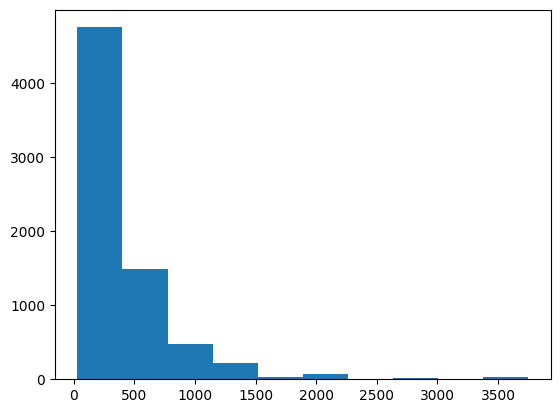

In [ ]:
plt.hist(df['Valor Final'])
plt.show()

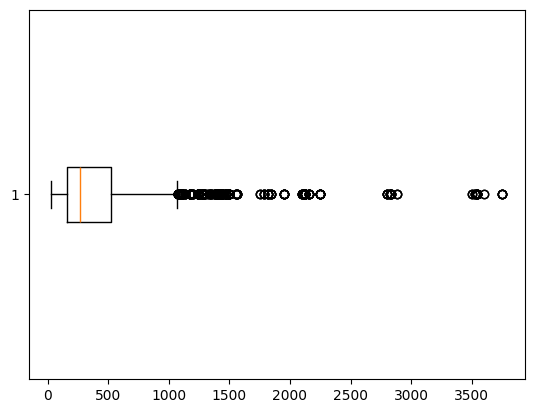

In [ ]:
plt.boxplot(df['Valor Final'], orientation='horizontal')
plt.show()

In [ ]:
df[df['Valor Final'] > 3000]

,Código Venda,Data,ID Loja,Produto,Quantidade,Valor Unitário,Valor Final
50,65049,2019-12-01,Iguatemi Esplanada,Terno Linho,5,750,3750
130,65104,2019-12-01,Salvador Shopping,Terno Estampa,5,706,3530
369,65263,2019-12-02,Center Shopping Uberlândia,Terno,5,700,3500
405,65286,2019-12-02,Bourbon Shopping SP,Terno Xadrez,5,709,3545
785,65568,2019-12-03,Bourbon Shopping SP,Terno,5,700,3500
1705,66166,2019-12-07,Shopping Ibirapuera,Terno Listrado,5,709,3545
2004,66379,2019-12-08,Iguatemi Campinas,Terno Listrado,5,709,3545
2666,66825,2019-12-10,Shopping Recife,Terno Listrado,5,709,3545
2798,66919,2019-12-10,Parque Dom Pedro Shopping,Terno Listrado,5,709,3545
3136,67180,2019-12-12,Shopping Morumbi,Terno Linho,5,750,3750


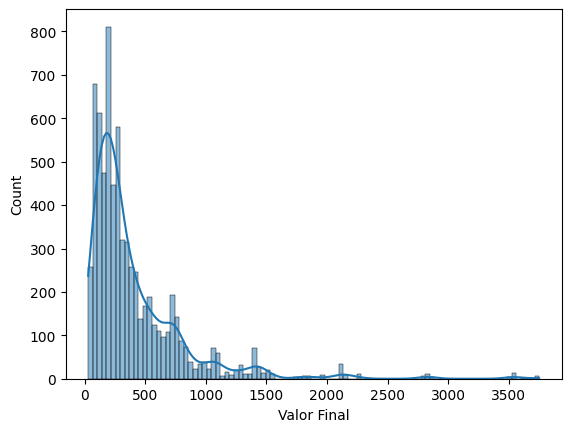

In [ ]:
sns.histplot(df["Valor Final"], kde=True)
plt.show()

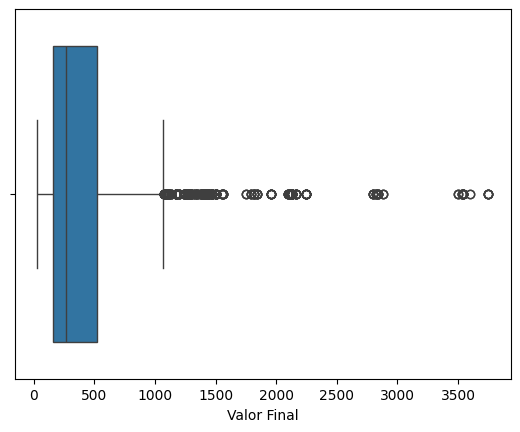

In [ ]:
sns.boxplot(x=df["Valor Final"])
plt.show()

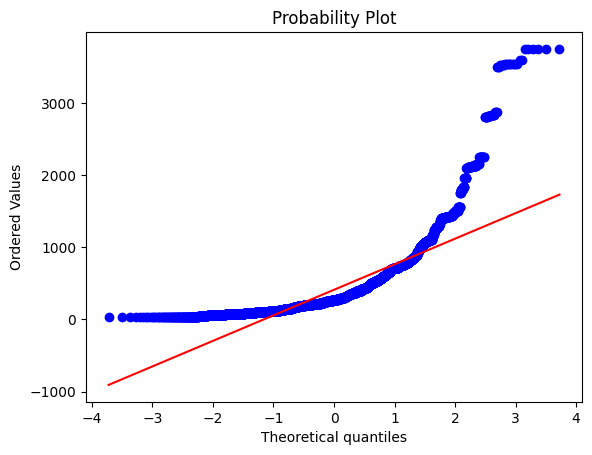

In [ ]:
stats.probplot(df["Valor Final"], dist="norm", plot=plt)
plt.show()

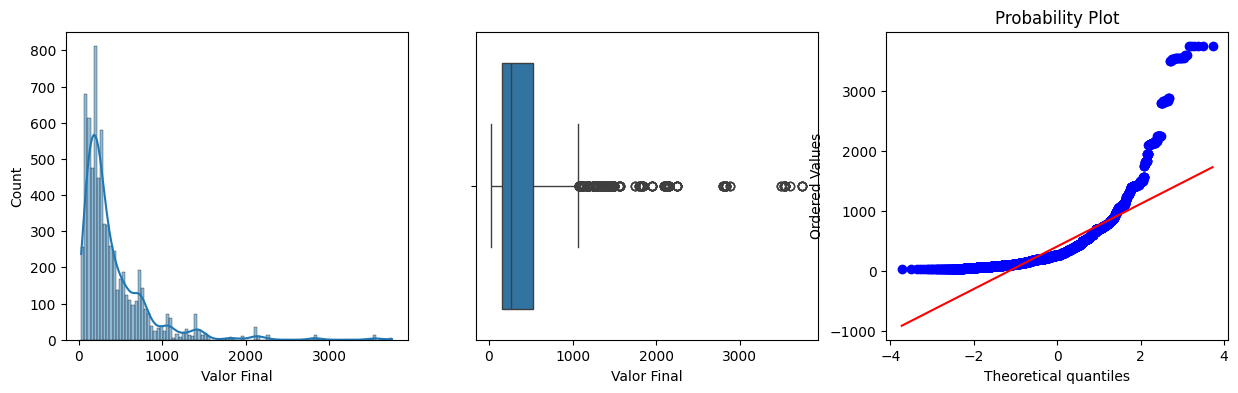

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

sns.histplot(df["Valor Final"], kde=True, ax=ax[0])
sns.boxplot(x=df["Valor Final"], ax=ax[1])

stats.probplot(df["Valor Final"], dist="norm", plot=ax[2])

plt.show()

In [ ]:
df['Valor Final'].skew()

np.float64(3.2044362810383444)

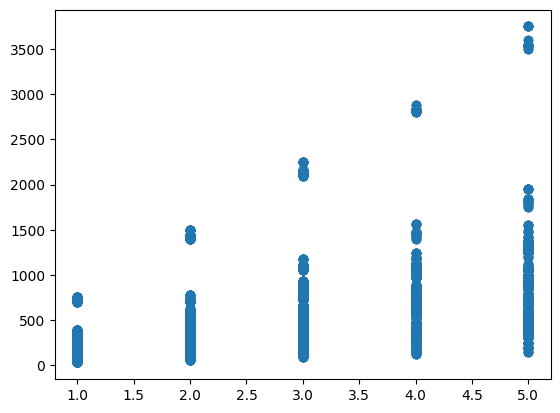

In [43]:
x = df['Quantidade']
y = df['Valor Final']
plt.scatter(x, y)
plt.show()

# **Analisis puntual para conocer algunos KPIs**

In [17]:
# Producto más caro (Tres (3) forma de obtenerlo)
ProductoCaro = df.loc[df['Valor Unitário'].idxmax(), ['Produto', 'Valor Unitário']].to_dict()
display(ProductoCaro)

{'Produto': 'Terno Linho', 'Valor Unitário': 750}

In [19]:
df[['Produto', 'Valor Unitário']].sort_values(by='Valor Unitário', ascending=False).head(1)

,Produto,Valor Unitário
4601,Terno Linho,750


In [20]:
df[['Produto', 'Valor Unitário']].sort_values(by='Valor Unitário', ascending=False).iloc[0]

,4601
Produto,Terno Linho
Valor Unitário,750


In [23]:
# Ranking de los cinco (5) productos más vendidos
top5 = df.groupby('Produto')['Quantidade'].sum().sort_values(ascending=False).head(5)
top5

,Quantidade
Produto,
Camisa Estampa,173
Polo Linho,163
Camiseta Xadrez,159
Camisa Gola V Liso,158
Pulseira Listrado,157


In [26]:
# La Venta más alta (Mayor Valor Final)
venta_mas_altas = df[['ID Loja', 'Valor Final']].max()
venta_mas_altas

,0
ID Loja,Shopping Vila Velha
Valor Final,3750


In [28]:
df.loc[df['Valor Final'].idxmax()]

,50
Código Venda,65049
Data,2019-12-01 00:00:00
ID Loja,Iguatemi Esplanada
Produto,Terno Linho
Quantidade,5
Valor Unitário,750
Valor Final,3750


#**KPIs de Rendimiento General**

In [44]:
# Ticket promedio por venta
ticket_promedio = df['Valor Final'].mean()
print(f"Ticket promedio: R$ {ticket_promedio:.2f}")

Ticket promedio: R$ 411.53


In [45]:
# Total de ingresos generales
ingresos_totales = df['Valor Final'].sum()
print(f"Ingresos totales: R$ {ingresos_totales:,.2f}")

Ingresos totales: R$ 2,917,311.00


In [46]:
#  Cantidad total de unidades vendidas
unidades_totales = df['Quantidade'].sum()
print(f"Unidades vendidas: {unidades_totales:,}")

Unidades vendidas: 15,227


# **Análisis Temporal**

In [47]:
# Ventas totales por mes
df['Mes'] = df['Data'].dt.to_period('M')
ventas_mes = df.groupby('Mes')['Valor Final'].sum().sort_index()
print(ventas_mes)

Mes
2019-12    2917311
Freq: M, Name: Valor Final, dtype: int64


In [48]:
# Mes con mayor volumen de ventas
mes_top = df.groupby('Mes')['Valor Final'].sum().idxmax()
print(f"Mejor mes: {mes_top}")

Mejor mes: 2019-12


In [52]:
# Día de la semana con más ventas
df['Dia_Semana'] = df['Data'].dt.day_name()
ventas_dia = df.groupby('Dia_Semana')['Valor Final'].sum().sort_values(ascending=False).head(1)
print(ventas_dia)

Dia_Semana
Monday    491086
Name: Valor Final, dtype: int64


#**Análisis por Sucursal**

In [ ]:
# Sucursal que más vende (No. de productos vendidos)
sucursal_top = df.groupby('ID Loja')['Quantidade'].sum().sort_values(ascending=False).head(1)
sucursal_top

,Quantidade
ID Loja,
Rio Mar Recife,767


In [61]:
# Sucursal que más vende (Ingresos por ventas)
sucursal_top = df.groupby(['ID Loja', 'Valor Final'])['Valor Final'].sum().idxmax()
sucursal_top

('Bourbon Shopping SP', np.int64(3545))

In [ ]:
# Ranking completo de sucursales (No de productos vendidos)
df.groupby('ID Loja')['Quantidade'].sum().sort_values(ascending=False)

,Quantidade
ID Loja,
Rio Mar Recife,767
Iguatemi Campinas,707
Salvador Shopping,669
Shopping Morumbi,653
Shopping Recife,652
Palladium Shopping Curitiba,645
Shopping Eldorado,644
Shopping Iguatemi Fortaleza,640
Center Shopping Uberlândia,633


In [ ]:
# Sucursal que más vende (Ingresos por ventas)
sucursal_top = df.groupby('ID Loja')['Valor Final'].sum().sort_values(ascending=False)
sucursal_top

,Valor Final
ID Loja,
Iguatemi Campinas,149959
Rio Mar Recife,139869
Shopping Recife,131871
Salvador Shopping,129156
Rio Mar Shopping Fortaleza,127890
Bourbon Shopping SP,125850
Center Shopping Uberlândia,124960
Shopping Eldorado,124339
Shopping Iguatemi Fortaleza,124182


In [62]:
# Ticket promedio por sucursal
ticket_sucursal = (df.groupby('ID Loja')['Valor Final'].mean().sort_values(ascending=False)
                     .round(2))
ticket_sucursal

,Valor Final
ID Loja,
Iguatemi Campinas,476.06
Shopping Recife,461.09
Bourbon Shopping SP,440.03
Rio Mar Shopping Fortaleza,435.00
Shopping Iguatemi Fortaleza,428.21
Salvador Shopping,427.67
Parque Dom Pedro Shopping,420.88
Novo Shopping Ribeirão Preto,417.17
Center Shopping Uberlândia,416.53


In [63]:
# Cantidad de transacciones por sucursal
transacciones = df.groupby('ID Loja')['Código Venda'].count().sort_values(ascending=False)
transacciones

,Código Venda
ID Loja,
Rio Mar Recife,366
Iguatemi Campinas,315
Shopping Morumbi,306
Shopping Eldorado,304
Salvador Shopping,302
Palladium Shopping Curitiba,301
Center Shopping Uberlândia,300
Shopping Vila Velha,299
Rio Mar Shopping Fortaleza,294


# **Resumen Ejecutivo de una sola vez**

In [64]:
print("=" * 45)
print("       RESUMEN EJECUTIVO DE VENTAS")
print("=" * 45)
print(f"Total ingresos:      R$ {df['Valor Final'].sum():>12,.2f}")
print(f"Total transacciones: {df['Código Venda'].count():>15,}")
print(f"Ticket promedio:     R$ {df['Valor Final'].mean():>12,.2f}")
print(f"Unidades vendidas:   {df['Quantidade'].sum():>15,}")
print(f"Mejor sucursal:      {df.groupby('ID Loja')['Valor Final'].sum().idxmax():>15}")
print(f"Producto top:        {df.groupby('Produto')['Quantidade'].sum().idxmax():>15}")
print(f"Mejor mes:           {str(df.groupby(df['Data'].dt.to_period('M'))['Valor Final'].sum().idxmax()):>15}")
print("=" * 45)

       RESUMEN EJECUTIVO DE VENTAS
Total ingresos:      R$ 2,917,311.00
Total transacciones:           7,089
Ticket promedio:     R$       411.53
Unidades vendidas:            15,227
Mejor sucursal:      Iguatemi Campinas
Producto top:         Camisa Estampa
Mejor mes:                   2019-12
